## **prep**

In [3]:
# importing packages 
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

In [4]:
# change to specific directory for user running code 
os.chdir("/Users/sophiekim/Desktop/2_research/MamalakisResearch") 
base_path = os.getcwd()

# everyone should have locally loaded 'data' folder
data_path = base_path + '/data/'

In [5]:
# initializing model list variable to call in function
model_list = [
    "CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
]

In [6]:
# pulling variables out for the plot function 
VAR_LIST = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

# dictionary for each unit for the plot 
UNIT_MAP = {
    "tas": "°C", 
    "tasmax": "°C", 
    "tasmin": "°C", 
    "pr": "mm/day", 
    "psl": "hPa", 
    "sfcWind": "m/s", 
    "mrsos": "kg/m²"}

## **functions**

### **converting units**

*converting units for the variables*

In [7]:
def convert_units(varname: str, x: np.ndarray):
    """
    varname: index number from the list of variables so get_data func can convert units 
    x: data that needs units changed (raw x data) in get_data func 
    """
    if varname in {"tas", "tasmax", "tasmin"}:
        # kelvin to celcius
        return x - 273.15, "$^{\circ}$C"
    if varname == "pr":
        # kg/m2/s to mm/day
        return x * 86400.0, "mm/day"
    if varname == "psl":
        # pascals to hpa
        return x / 100.0, "hPa"
    
    # these don't need to be converted -- just adding the units 
    if varname == "sfcWind":
        return x, "m/s"
    if varname == "mrsos":
        return x, "kg/m$^{2}$"
    return x, "unknown"

### **cnn tensor prep**

*calculates x_data tensor that calculates statistical summary for a certain variable (ie tas, tasmax, etc.) for specified early and late periods (also a baseline). can also calculate the difference between the early and late periods with the baseline yrs of 2015 and 2024. returns x_data tensor and y_data tensor (y_data tensor gives back a 2d tensor of [# of samples, 1] that gives binary labels (0 for early, 1 for late) for every variable value calculated)*

In [8]:
def get_model_name(path: str) -> str:
    """
    helper function so that get_cnn_tensors prints out the models that are being processed
    pulled from hayeon's code 
    """
    # Everything before "_ssp..."
    return os.path.basename(path).split("_ssp")[0]

In [20]:
def get_cnn_tensors(model_list, scenario, data_path, 
                    st_early=2015, end_early=2024, 
                    st_late=2050, end_late=2059,
                    stat='mean', use_anomaly=True, 
                    models_to_run=None, file_start_year=2015, 
                    vars_to_use=None):
    """
    model_list: variable of list of models
    scenario: input as either 'ssp119' or 'ssp126' strings
    data_path: variable of data_path for user
    st_early: early period start yr integer
    end_early: early period end yr integer
    st_late: late period start yr integer
    end_late: late period end yr integer
    stat: what stat function user wants to run to summarize variables 
        mean: mean
        std: standard deviation
        max: max val
        min: min val
        medium: median
    use_anomaly: whether to subtract values from baseline values to find anomaly
        True: subtract values
        False: don't subtract values 
    models_to_run: can specify number of models to run by index of model_list variable
        None: all models 
        [x]: one model to run 
        [x, x, x...]: whatever number of models to run 
    file_start_year: ensuring that if time dimension in models starts at 0 or 1, the func will slice the time correctly 
    vars_to_use: give list of strings of vars to calculate, if none specified (aka default) then does all 7 vars
    """
    
    # defining variable list for unit conversion later 
    var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]
    # default of calculating with all 7 vars 
    if vars_to_use is None:
        selected_vars = var_list
    # if user specified certains vars to be calculated
    else:
        # check to see that the string items provided do exist
        selected_vars = [v for v in vars_to_use if v in var_list]

    # find the indexes of the specified variables defined by user (or defaulting to finding all the vars' indices)
    var_indices = [var_list.index(v) for v in selected_vars]

    # mapping out stats and the relevant func
    stat_map = {'mean': np.nanmean, 'std': np.nanstd, 'max': np.nanmax, 'min': np.nanmin, 'median': np.nanmedian}
    # variable that will calculate the stat for whatever the user wants and then will default to mean 
    calc_func = stat_map.get(stat.lower(), np.nanmean)


    # runs all models 
    if models_to_run is None:
        selected_models = model_list
    # runs one model if user only specified one 
    elif isinstance(models_to_run, int):
        selected_models = [model_list[models_to_run]]
    # if none of the above options (all or one) was selected, then was list of models so get those models 
    else:
        selected_models = [model_list[i] for i in models_to_run]


    # intilaizing x & y lists 
    x_list, y_list = [], []

     # opening file 
    for filename in selected_models:
        full_path = os.path.join(data_path, filename)
        model_short_name = get_model_name(filename)
        print(f"processing model: {model_short_name}")
        
        with nc.Dataset(full_path) as ds:
            # loading the data for specific model 
                # slicing dimensions for the ensembles, the specific var indices and all the times/long/lat dimensions
            data_all_vars = ds[f"data_{scenario}"][:, var_indices, :, :, :] 

            # starting unit conversions for ALL variables
            print(f"converting units in {len(var_list)} variables")
            # looping through all 7 vars or the selected vars only 
                # using enumerate to keep track of the index of var and what the var is in the var_list defined above
                    # idx to keep track of what slice of the var dimension 
                    # var_name so that convert_units can be called correctly 
            for idx, var_name in enumerate(selected_vars):
                # converting var to relevant unit from func -- slicing the relevant var one at a time (getting all the info for all the other dimensions, just associated with that certain var)
                    # returns the converted numbers and string that gives converted unit
                converted_data, unit_str = convert_units(var_name, data_all_vars[:, idx, :, :, :])
                # taking all the converted data and making it the 'all data' version for the var index 
                data_all_vars[:, idx, :, :, :] = converted_data
            
            # checking time variable 
            time_var = ds.variables['time']
            print(f"Time units: {time_var.units} | First time index: {time_var[0]}")

            # initializing period list where early period yrs assigned 0 and late period yrs assigned 1
            periods = [(st_early, end_early, 0), (st_late, end_late, 1)]
        
            # looping through the individual items in the list items in the period variable 
            for start_yr, end_yr, label in periods:
                # initializing period_sample list 
                    # empties after first list item iteration aka empties when early period is done, then moves to late period 
                period_samples = []
                # looping through yrs in the range of the start yr and end yr (+1 bc of range func)
                for yr in range(start_yr, end_yr + 1):
                    # getting starting month by getting yr and then subtracting from the file start yr (which is 2015) and then multiplying by 12
                    m_start = (yr - file_start_year) * 12
                    # end of that yr by adding 12 to start month 
                    m_end = m_start + 12
                    # getting yearly summary for all ensembles in that certain 1 yr time frame for all the vars 
                    yearly_stat = calc_func(data_all_vars[:, :, m_start:m_end, :, :], axis=2)
                    # appending the yearly_stat array to the period_samples list
                    period_samples.append(yearly_stat)
            
                # making the period_samples a numpy array 
                    # should be the 10 yr period for each early period and then again for late period 
                    # [10, 5, 7, lat, lon]
                pool_array = np.array(period_samples)
                # assigning each dimension their respective shape
                n_years, n_ens, n_vars, n_lat, n_lon = pool_array.shape
                # getting N value for normalization of vars by multiplyng dimensions of yrs and ensemble dimensions    
                    # aka 10 (yrs) * 5 (ensembles)
                N = n_years * n_ens

                # since code above has too many dimensions, flatten it out so that is all the unique traj/yrs together in one dimension (aka all the unique maps there are for each yr --- before, it was split up by unique yr and also unique traj)
                pool_flat = pool_array.reshape(N, n_vars, n_lat, n_lon)
                
                # MATH PART
                # getting mean for each grid point in the 50 samples 
                    # so like each lat/lon unique combo has 50 samples, and those 50 samples in that lat/long unique combo gets aaveraged tg 
                p_mean = np.nansum(pool_flat, axis=0) / N
                # subtracting each sample yr from the mean calcualted above then squares it 
                    # aka looking at total spread of data 
                diff_sq = (pool_flat - p_mean)**2
                # stanard deviation calculation 
                    # the summing partcalculates variance 
                        # sums the squared differneces across the 50 samples and then divides by 50 aka N
                    # then square rooting bc std
                    # this gives back map of [7, lat, long] where each pixel says how much the specific variable/channel fluctuates 
                        # low value means stable climate
                p_std = np.sqrt(np.nansum(diff_sq, axis=0) / N)
                # making any 0 std 1 so doesn't cause issues later 
                p_std[p_std == 0] = 1.0
           

                print(f"period is {label} ({start_yr}-{end_yr})and the number of samples is {N}")
                print(f"mean is: {np.nanmean(p_mean)} and std is: {np.nanmean(p_std)}")

                # looping through one yr (getting the start and end yrs from the periods list defined above)
                for yr_idx in range(start_yr, end_yr + 1):
                    # so need to calculate an index of a yr since it's in months
                        # subtracting the current yr index that is being looped thru from 2015 since that's when model starts
                            # then multiplying that val by 12 since need it in months units
                        # ok to have first month be value 0 since python list index starts at 0 (even tho in data, month starts at 1)
                    m_idx_start = (yr_idx - file_start_year) * 12
                    m_idx_end = m_idx_start + 12
                    
                    # looping through every ensemble in each model 
                        # hypothetically runs 5 times since 5 traj 
                    for ens_idx in range(n_ens):
                        # slicing for one traj, all 7 vars, the current yr, and all lats/longs
                            # so should be one yrs worth of monthly data for one traj in the model 
                            # resulting shape should be [7, 12, lat, lon]
                                # so 7 variables, 12 months, lat, lon -- for the certain sliced out traj 
                        annual_slice = data_all_vars[ens_idx, :, m_idx_start:m_idx_end, :, :]
                        # calling calc_func var to calculate whatever statistical summarization func on the annual slice
                            # averaging across axis 1 (aka time dimension)
                        yearly_val = calc_func(annual_slice, axis=1) 
                        
                        # if the use_anaomly is true, then you standardize 
                        if use_anomaly:
                            val = (yearly_val - p_mean) / p_std
                        # if use_anomly is false, then you just use the summarized year vals 
                        else:
                            val = yearly_val
                        
                        # append calculated vals and 0/1 labels to x & y lists respectively
                        x_list.append(val)
                        y_list.append(label)

    # adding everything to array format 
    x_data = np.array(x_list) 
    # reshaping y data so becomes 2d col vector rather than a 1d list 
        # -1 says to figure out how many rows needed to fit data and 1 says to have exactly one col 
        # so goes from [0, 1, etc] to [[0], [1], [etc]]
    y_data = np.array(y_list).reshape(-1, 1)
    
    print(f"final x_data shape: {x_data.shape}")
    return np.nan_to_num(x_data, nan=0.0), y_data

### **plot function**

In [10]:
# initializing var_list
VAR_LIST = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

# initalizing unit dictionary 
UNIT_MAP = {
    "tas": "°C", 
    "tasmax": "°C", 
    "tasmin": "°C", 
    "pr": "mm/day", 
    "psl": "hPa", 
    "sfcWind": "m/s", 
    "mrsos": "kg/m²"}

*this provides a plot calculated from the x_data and y_data tensors from above function. splits x_data into its respective early and late periods using the indices of binary labels from the y_data. values on plot are averages across the values for the early and late periods, besides the third plot which provides the signal (or difference between the early and late periods).*

In [18]:
def plot_all_variables(x_data, y_data):
    """
    x_data: shape (samples (should be 500), 7, lat, lon)
    y_data: shape (samples (should be 500), 1)
    """
    # initializing variable list 
    var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]
    
    # indexing out where the early and late periods are 
        # adding [0] to end so that it doesn't give back the actual y data labels, just returns the row index 
    early_indices = np.where(y_data == 0)[0]
    late_indices = np.where(y_data == 1)[0]
    
    # PLOTTING INDIVID VARS
    # looping through the var list and ensuring that the var_name is also saved when going through each index val in list
    for i, var_name in enumerate(var_list):
        # calculating the avg for all the early period rows and for whatever var value
            # axis 0 collapses sample dimension (first dimension) so you get the average vals for the variable for each lat/lon
        early_mean = np.mean(x_data[early_indices, i, :, :], axis=0)
        late_mean = np.mean(x_data[late_indices, i, :, :], axis=0)
        # using the helper func below to plot for each var 
        plot_comparison_grid(early_mean, late_mean, f"variable: {var_name}")


    # PLOTTING ALL VARS AVERAGED
    # averaging al the x_data tg based on variable dimension 
    multivariate_data = np.mean(x_data, axis=1) 
    
    # indexing out where the early and late periods are 
    early_multi = np.mean(multivariate_data[early_indices], axis=0)
    late_multi = np.mean(multivariate_data[late_indices], axis=0)
    
    # using helper func below to plot this one 
    plot_comparison_grid(early_multi, late_multi, "multivariate plot of all 7 vars averaged together")


def plot_comparison_grid(early_map, late_map, main_title):

    # calculating the diff between the late and early
        # positive = var increased (warmer, wetter, etc)
        # negative = var decreased (drier, colder, etc) 
    signal = late_map - early_map
    # transposing everything so that lat and longs make sense 
    maps = [early_map.T, late_map.T, signal.T]
    # gives titles for the 3 subplots 
    titles = ["early period avg", "late period avg", "difference (late - early period)"]
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    plt.suptitle(main_title, fontsize=18, fontweight='bold', y=1.05)
    
    # loop runs three times for early, late and difference 
    for j in range(3):
        # for the early and late plots 
        if j < 2:
            # calculate min and max vals for the colorbar looking at the min/max vals for both the early and late periods
            vmin = min(np.nanmin(maps[0]), np.nanmin(maps[1]))
            vmax = max(np.nanmax(maps[0]), np.nanmax(maps[1]))
            cmap = 'viridis'
        else:
            # finding max values of absolute vals (whats the biggest difference found)
            sig_limit = np.nanmax(np.abs(maps[j]))
            # if there's no change, still need some sort of color bar, so if it's 0 then make it 0.1
            if sig_limit == 0: sig_limit = 0.1 
            # making min max values by using the val found above and doing neg and pos versions
            vmin, vmax = -sig_limit, sig_limit
            cmap = 'RdBu_r'
        # 
        im = axes[j].imshow(maps[j], origin='lower', cmap=cmap, 
                            vmin=vmin, vmax=vmax, aspect='auto')
        axes[j].set_title(titles[j], fontsize=14)
        cb = fig.colorbar(im, ax=axes[j])
        cb.set_label("standardized differences from baseline vals", fontsize=10)
        axes[j].set_xlabel("longitude")
        axes[j].set_ylabel("latitude")

    plt.tight_layout()
    plt.show()   

 for diverging color maps: 
- https://matplotlib.org/3.1.3/gallery/color/colormap_reference.html 

for sequential color maps: 
- https://matplotlib.org/stable/users/explain/colors/colormaps.html
- https://matplotlib.org/stable/users/explain/colors/colormaps.html


### **running functions**

In [22]:
x_data, y_data = get_cnn_tensors(model_list, 'ssp119', data_path, use_anomaly=True) 

processing model: CNRM_ESM2-1
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 53.85261595848958 and std is: 0.9132424100937383


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_1611/3886834280.py:108: RuntimeWarning: Mean of empty slice
  yearly_stat = calc_func(data_all_vars[:, :, m_start:m_end, :, :], axis=2)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_1611/3886834280.py:165: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


period is 1 (2050-2059)and the number of samples is 50
mean is: 53.94907913841443 and std is: 0.9052018070921246
processing model: MIROC6
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 51.49507460751535 and std is: 0.9218822667300146
period is 1 (2050-2059)and the number of samples is 50
mean is: 51.58029276891093 and std is: 0.904182765105488
processing model: MPI-ESM1-2-LR
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 41.457000812310824 and std is: 0.9244298500040711
period is 1 (2050-2059)and the number of samples is 50
mean is: 41.503712878956044 and std is: 0.9123206133564625
processing model: MRI-ESM2-0
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 50.09519157501135 and std is: 0.913319863048491
period is 1

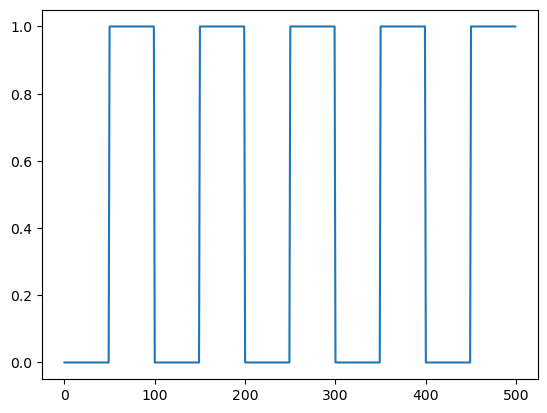

In [23]:
plt.plot(y_data)

^ the plot output in this case makes sense, since function now loops through one model at a time, so should be 50 (bc one model, 5 trajectories, 10 yrs) of early (so 0) and then late (so 1)

In [24]:
x_data.shape

(500, 7, 144, 73)

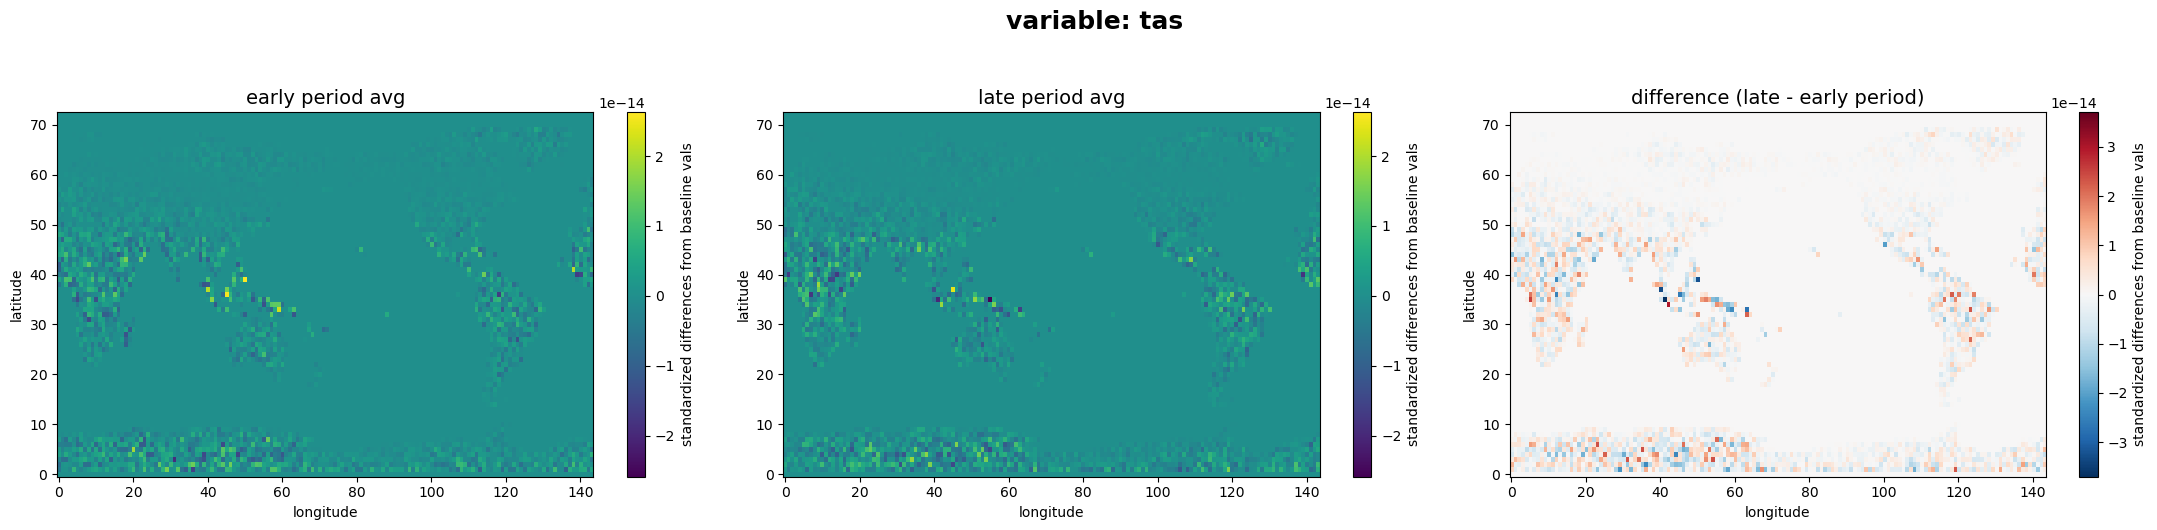

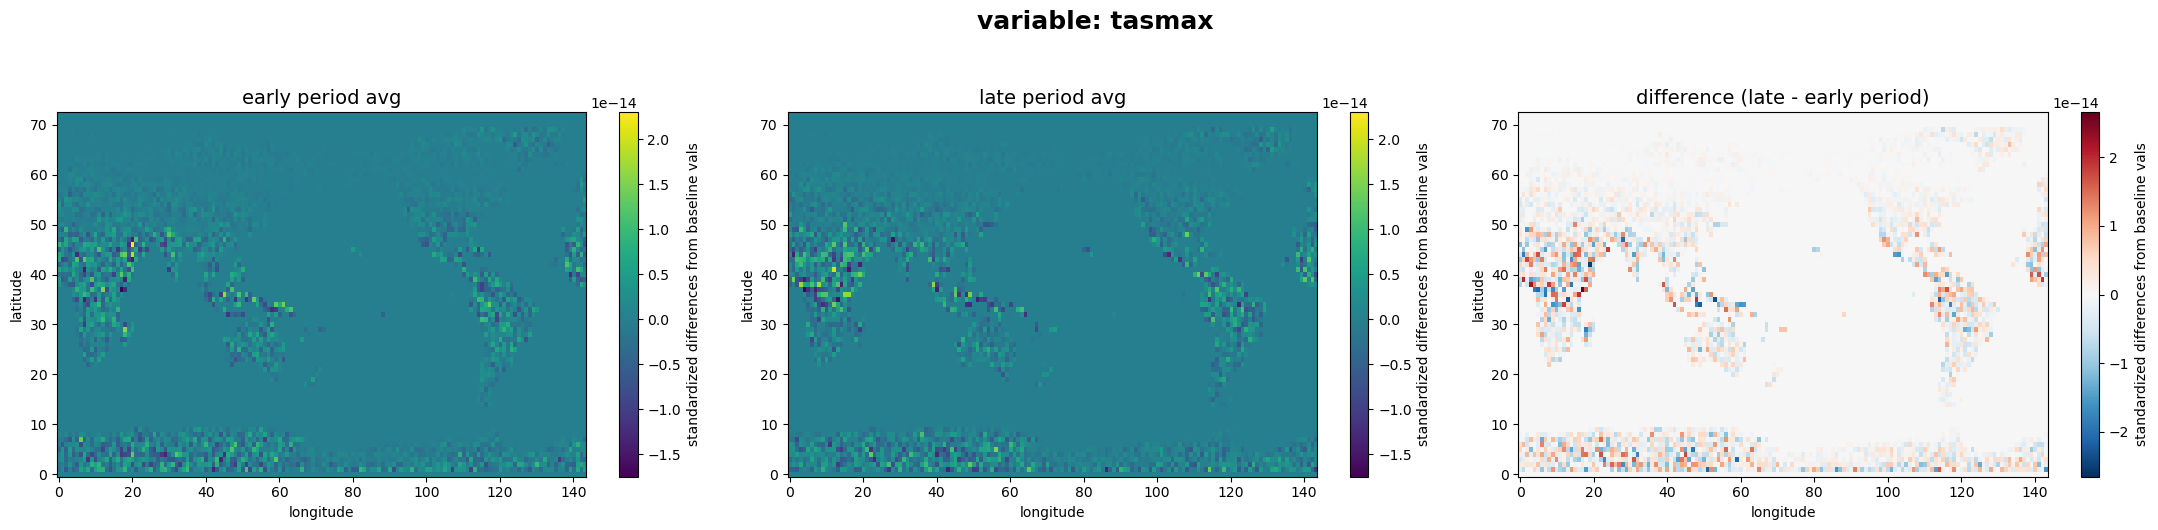

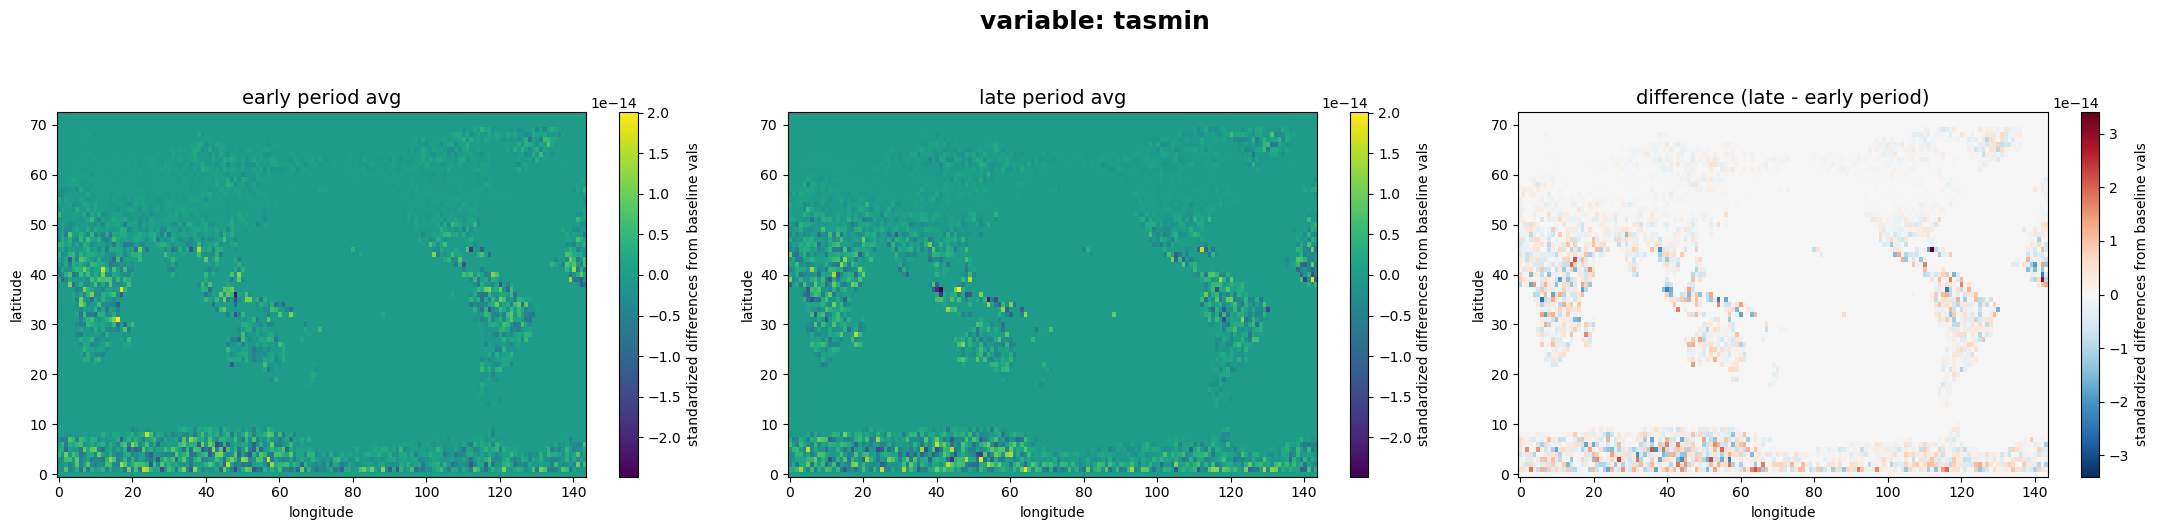

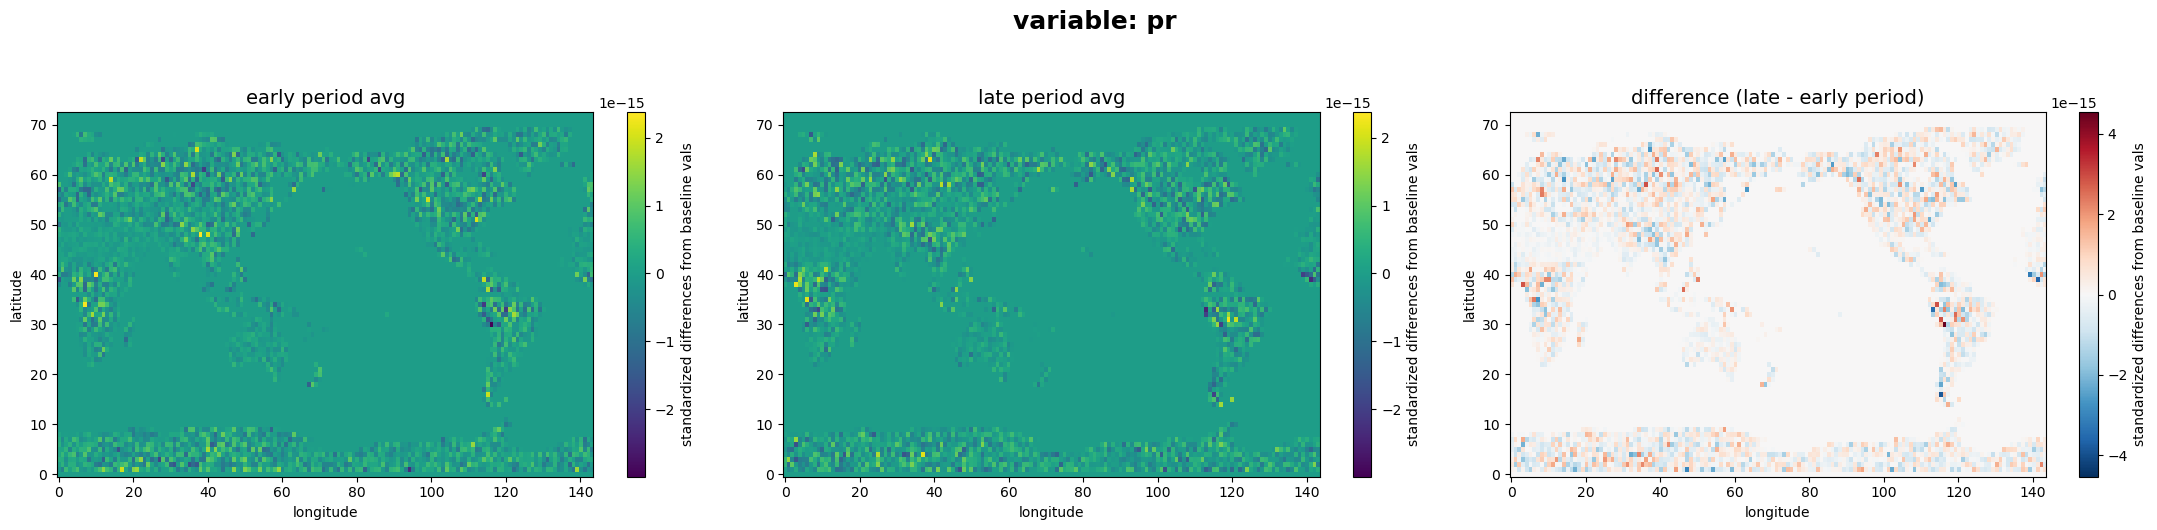

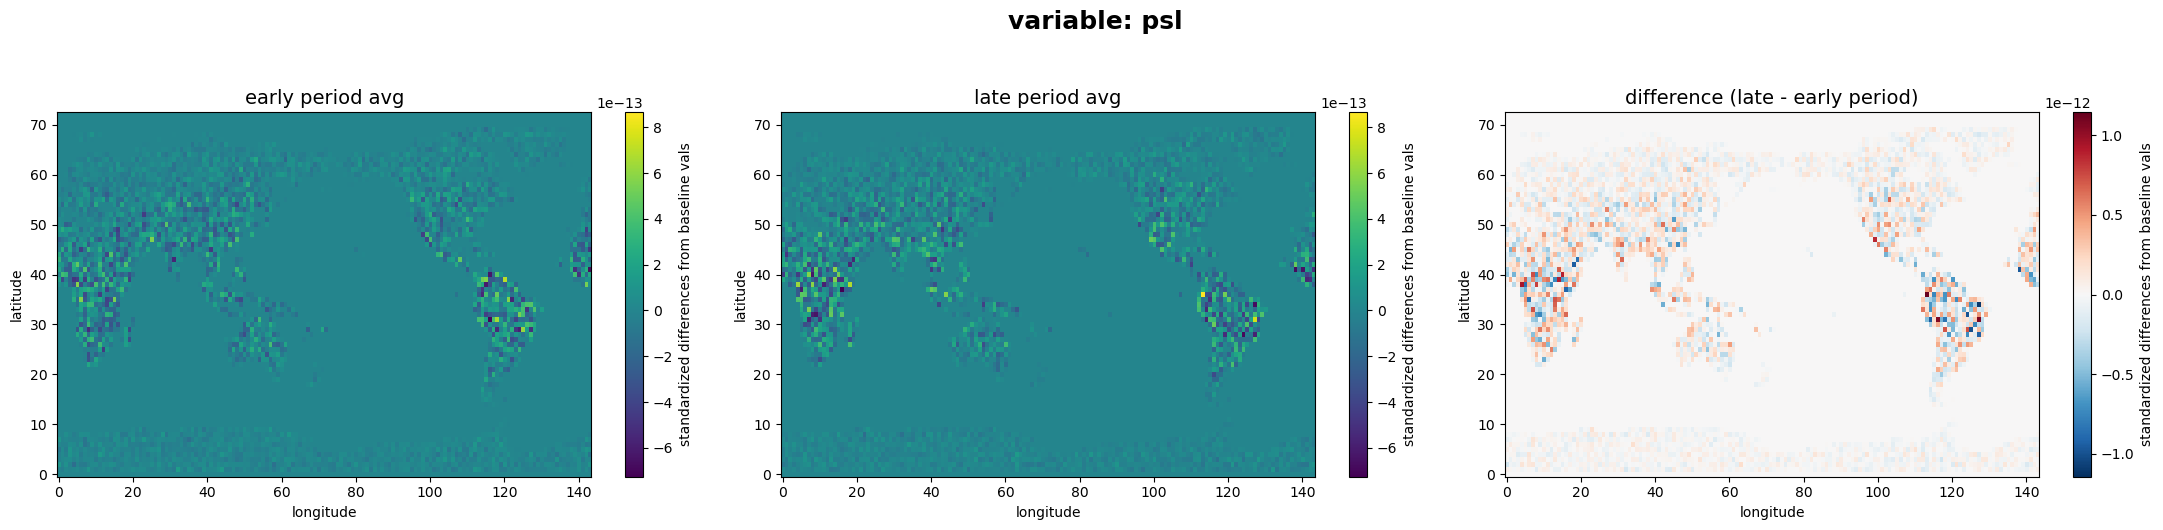

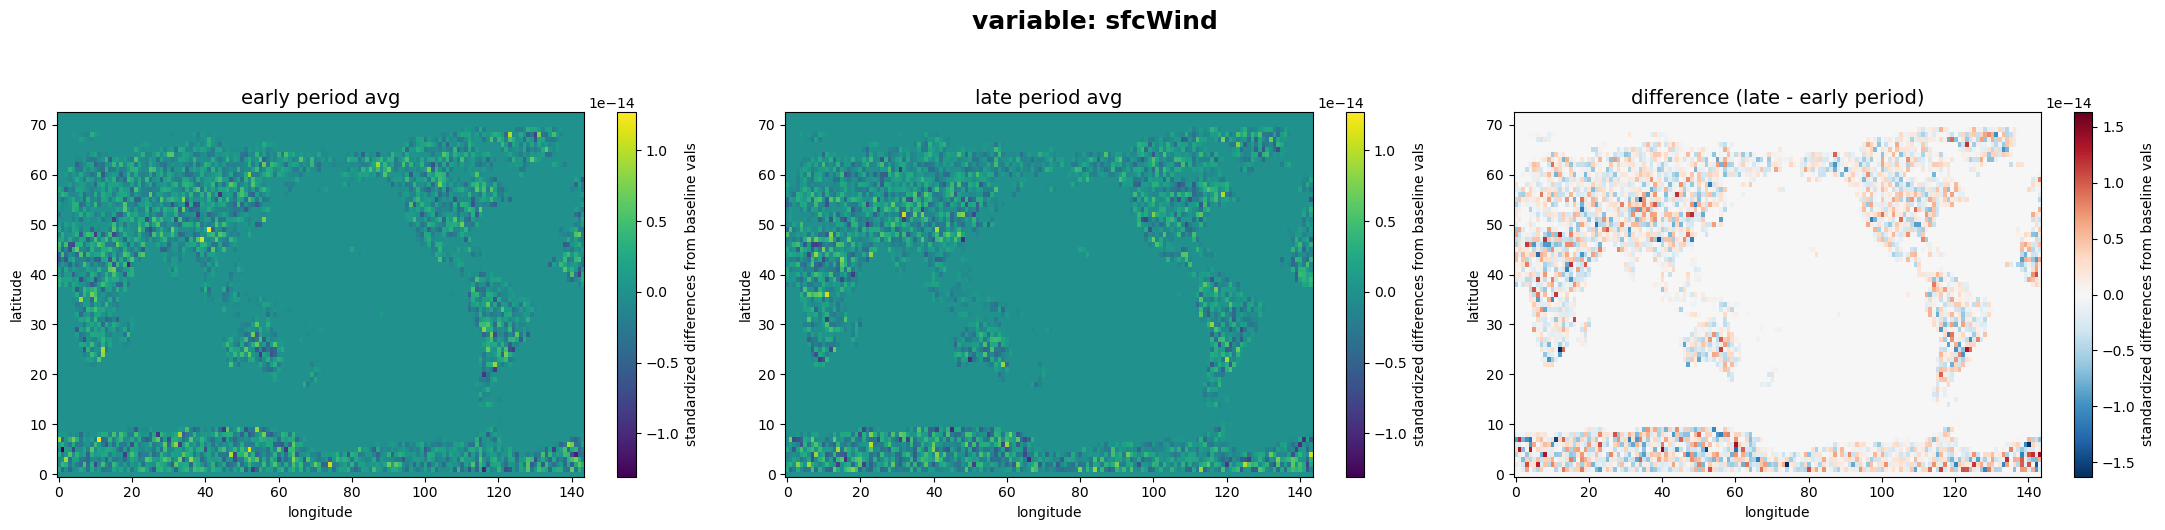

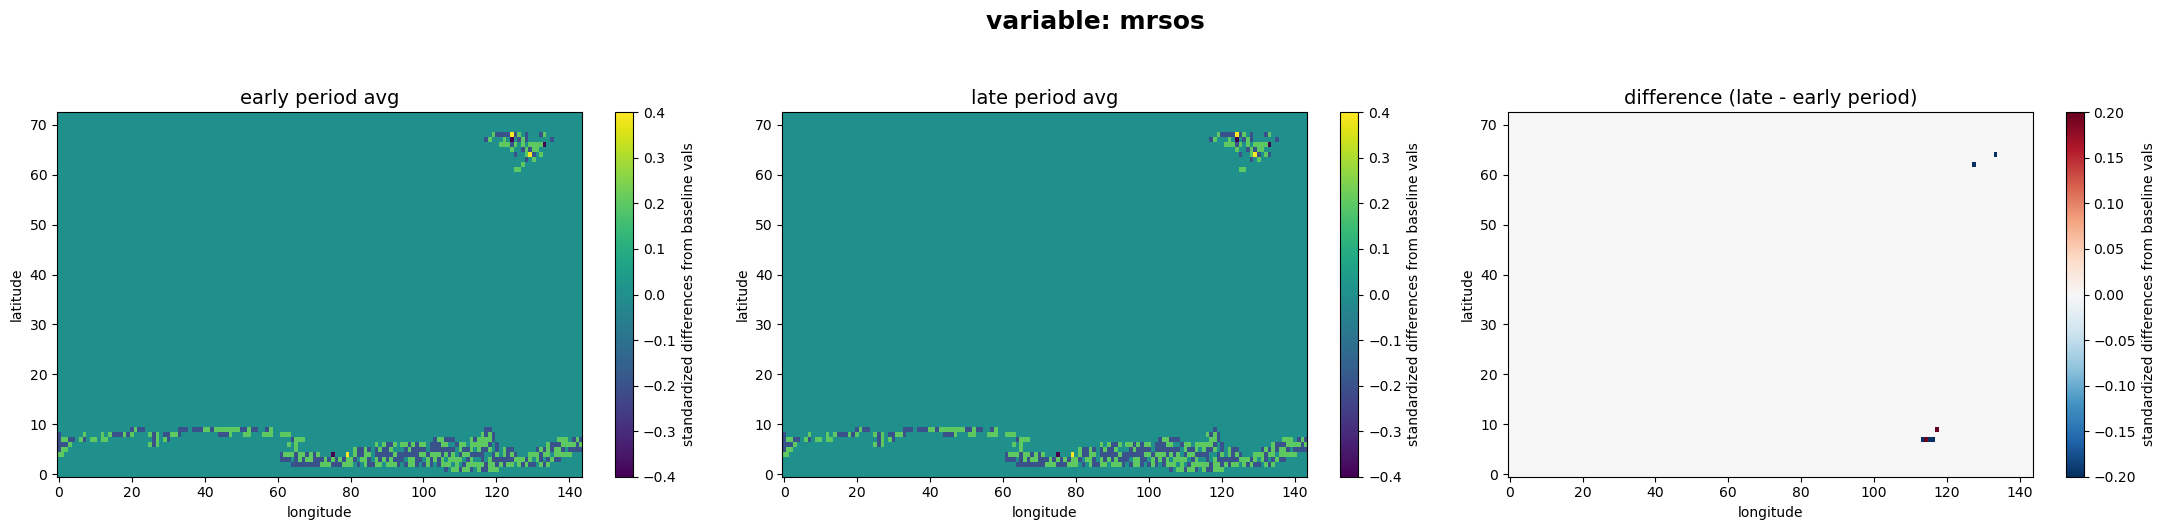

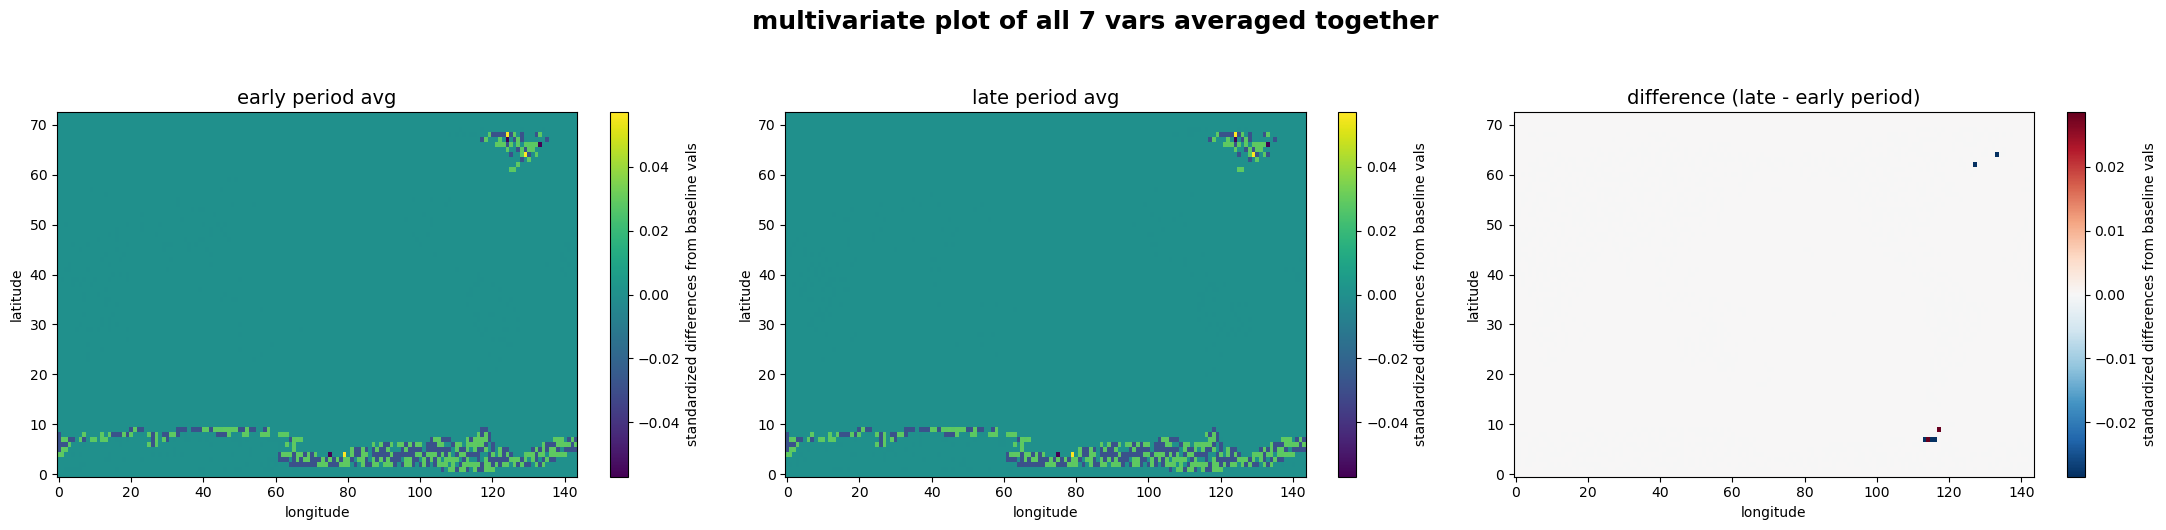

In [25]:
plot_all_variables(x_data, y_data)

In [26]:
x_data, y_data = get_cnn_tensors(model_list, 'ssp119', data_path, use_anomaly=False) 

processing model: CNRM_ESM2-1
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 53.85261595848958 and std is: 0.9132424100937383


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_1611/3886834280.py:108: RuntimeWarning: Mean of empty slice
  yearly_stat = calc_func(data_all_vars[:, :, m_start:m_end, :, :], axis=2)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_1611/3886834280.py:165: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


period is 1 (2050-2059)and the number of samples is 50
mean is: 53.94907913841443 and std is: 0.9052018070921246
processing model: MIROC6
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 51.49507460751535 and std is: 0.9218822667300146
period is 1 (2050-2059)and the number of samples is 50
mean is: 51.58029276891093 and std is: 0.904182765105488
processing model: MPI-ESM1-2-LR
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 41.457000812310824 and std is: 0.9244298500040711
period is 1 (2050-2059)and the number of samples is 50
mean is: 41.503712878956044 and std is: 0.9123206133564625
processing model: MRI-ESM2-0
converting units in 7 variables
Time units: months | First time index: 1.0
period is 0 (2015-2024)and the number of samples is 50
mean is: 50.09519157501135 and std is: 0.913319863048491
period is 1

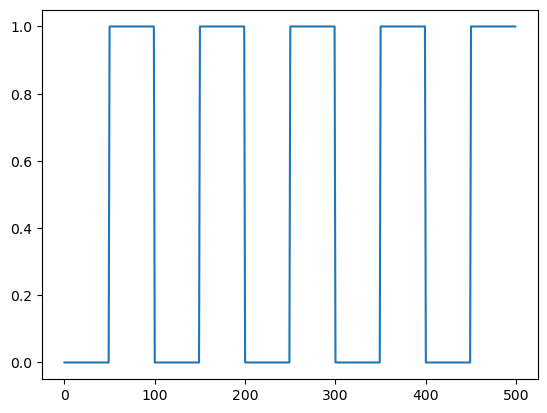

In [27]:
plt.plot(y_data)

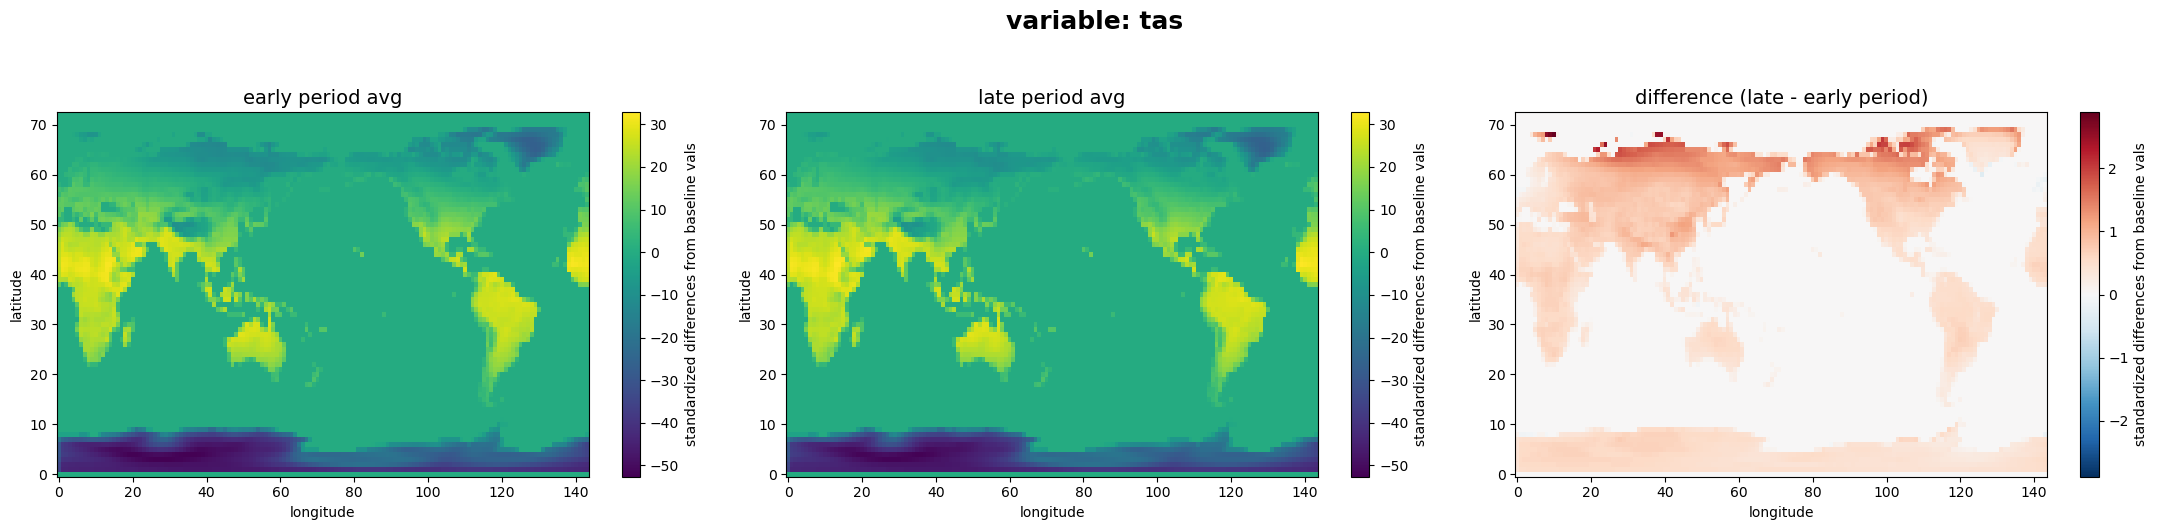

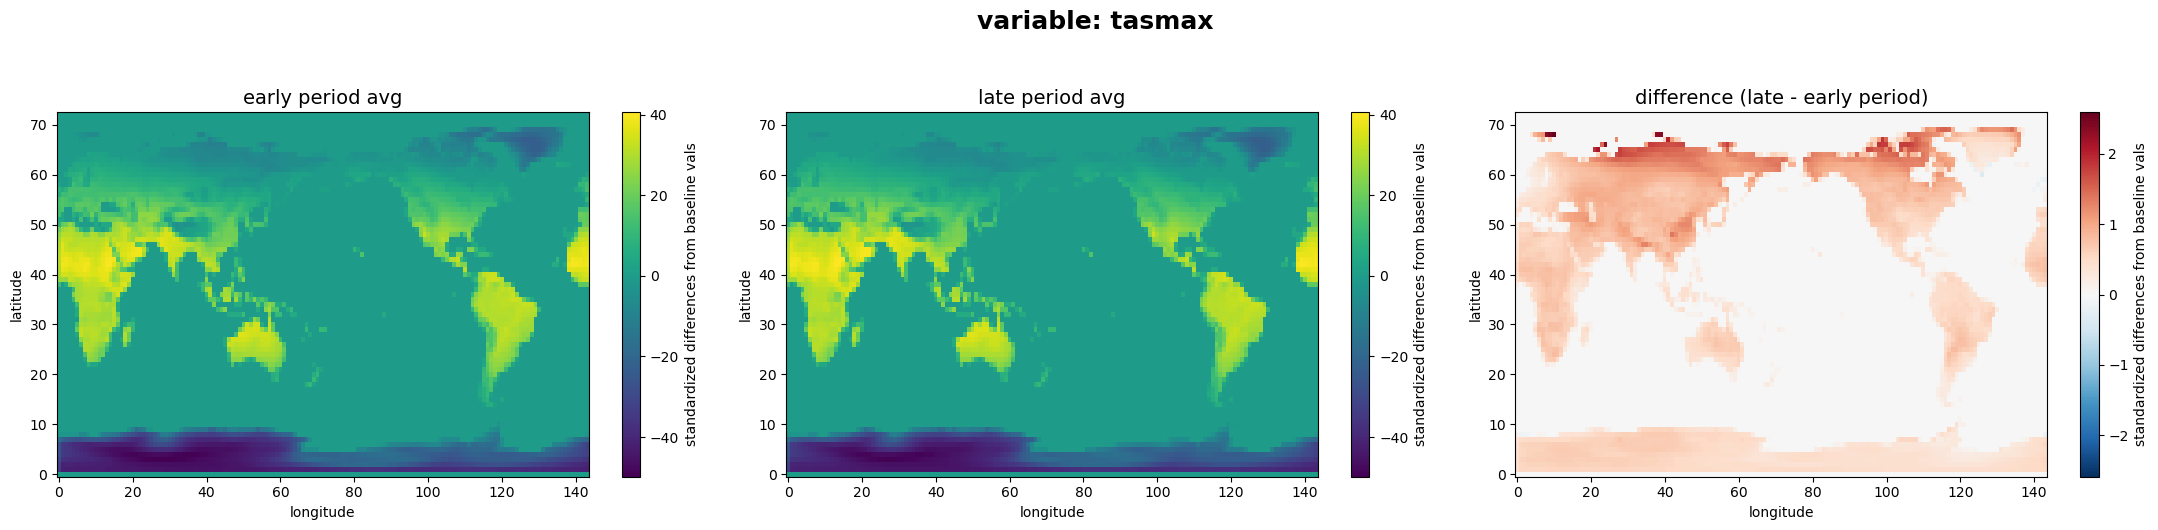

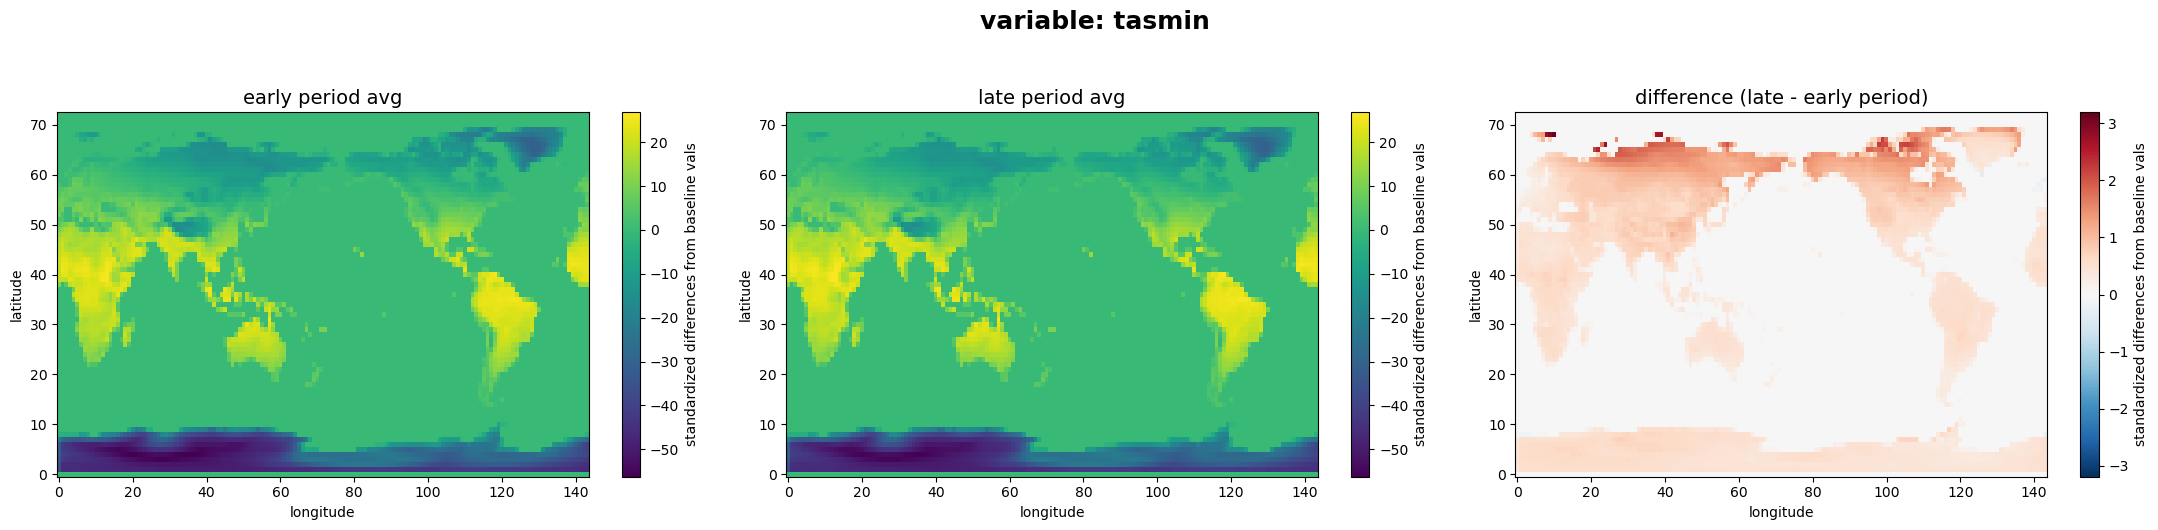

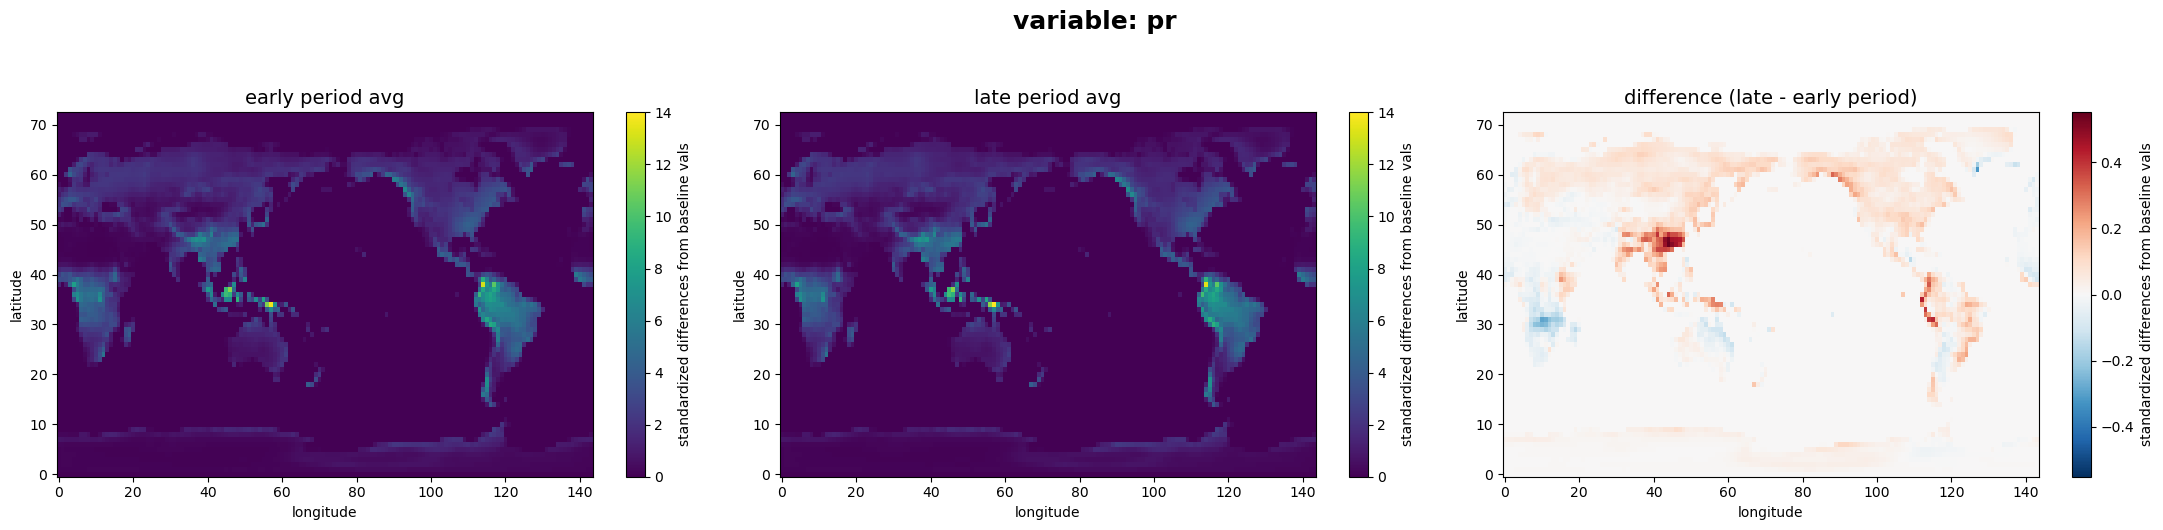

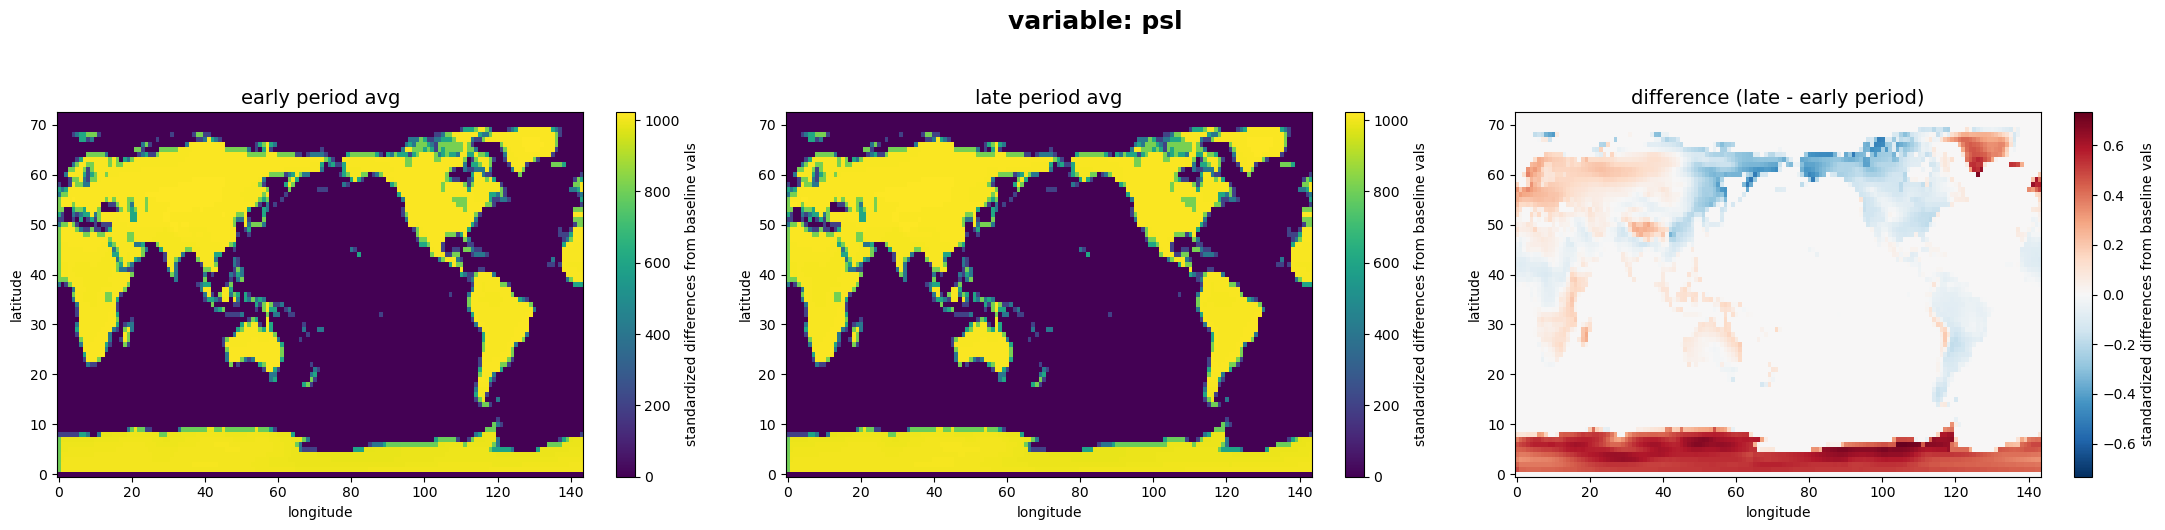

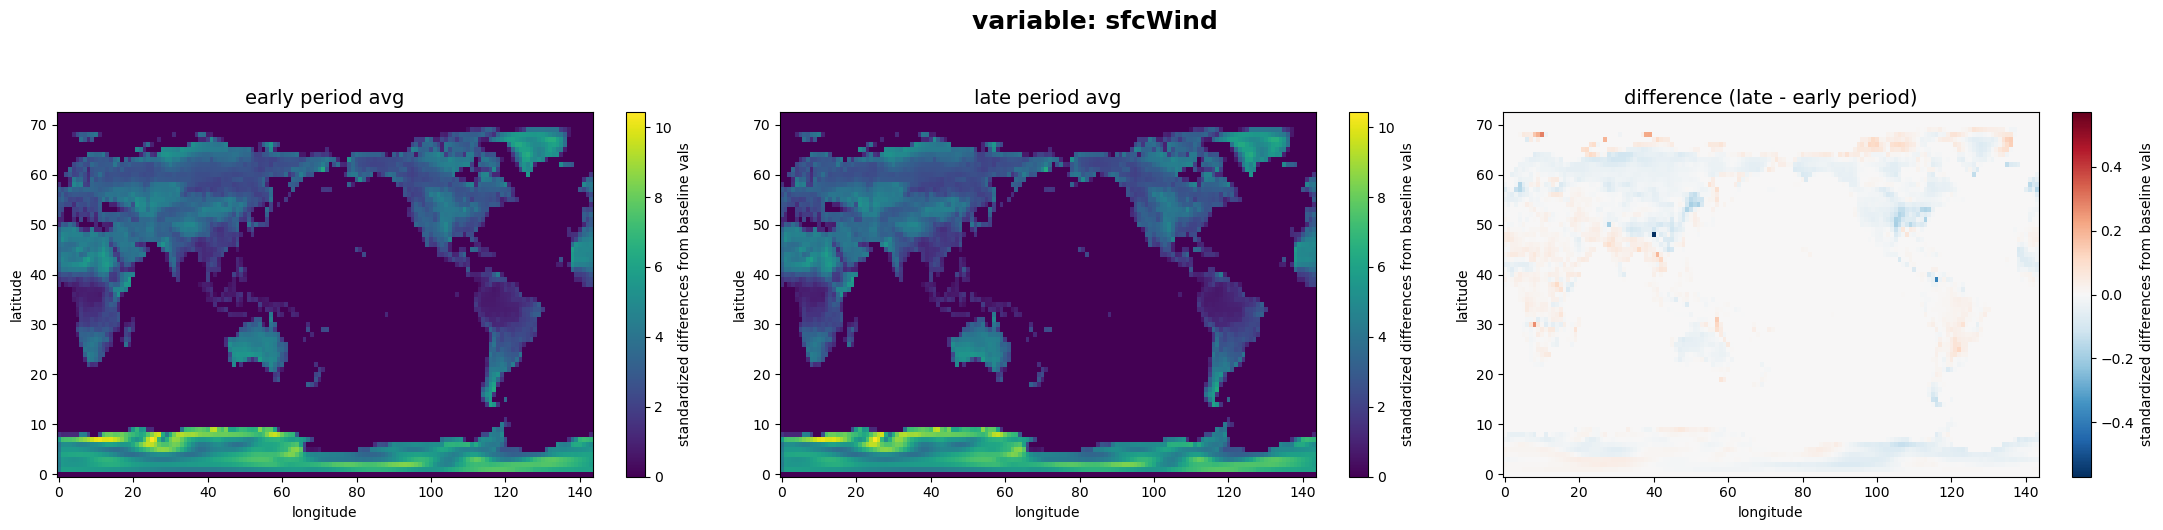

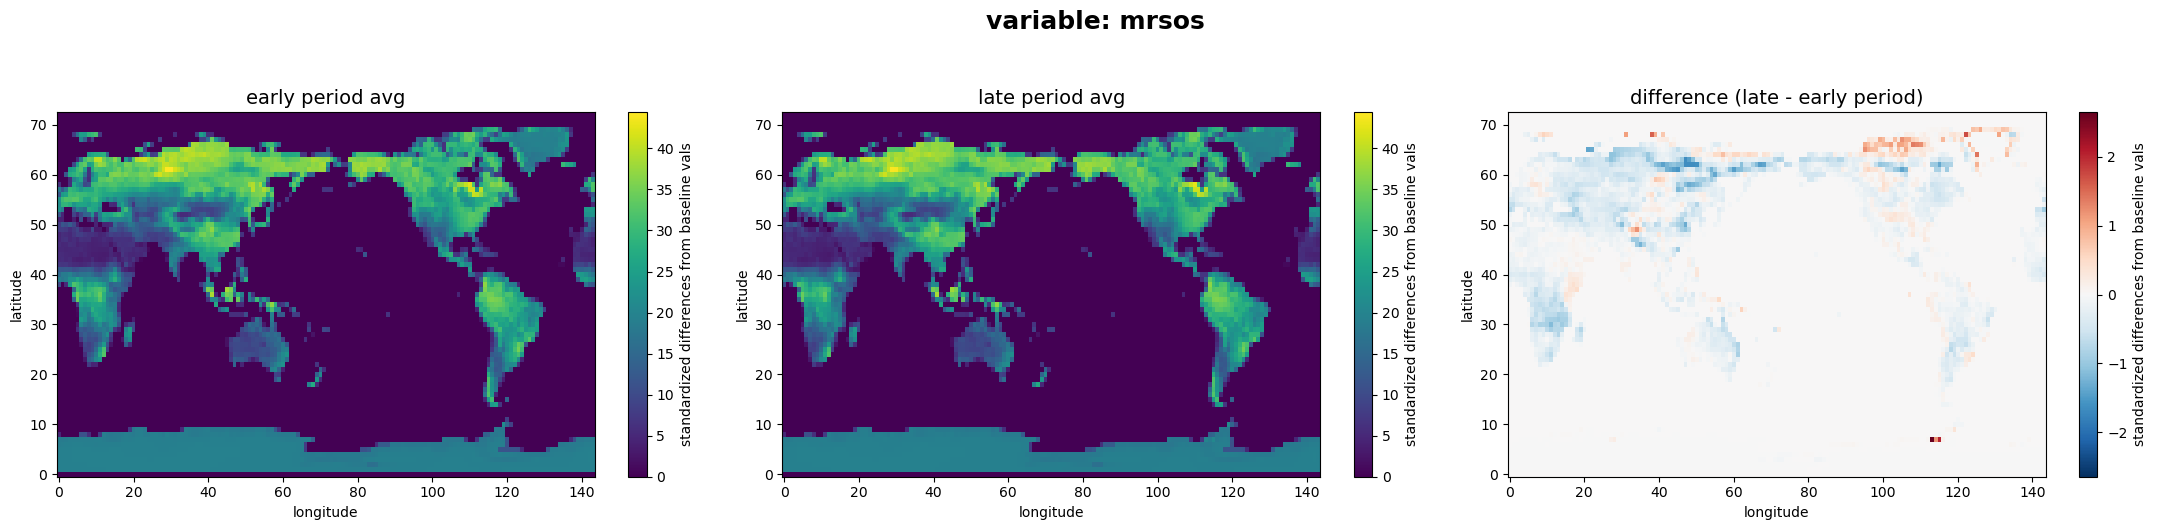

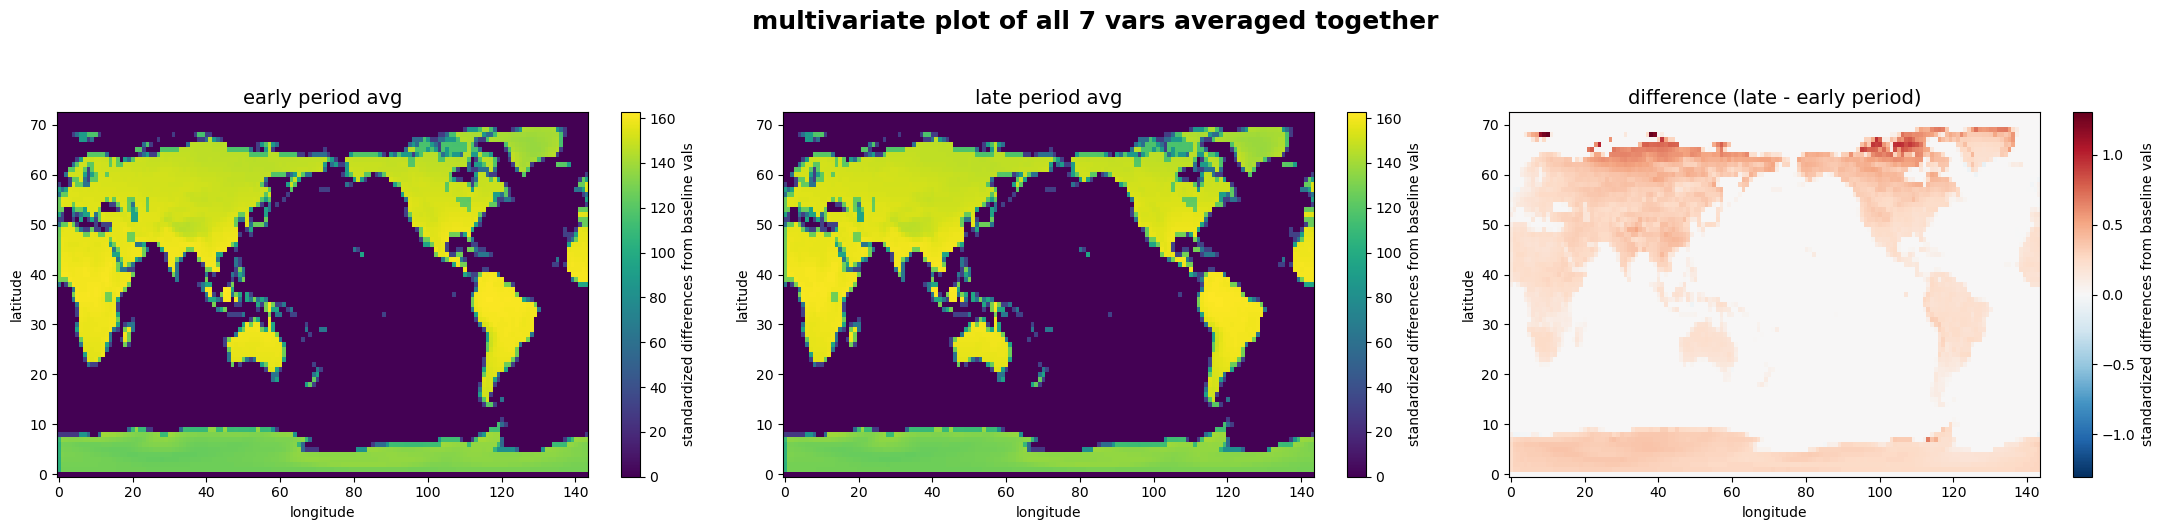

In [29]:
plot_all_variables(x_data, y_data)